#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from pathlib import Path
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

from joblib import Parallel, delayed
import multiprocessing

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *
from bayesian_forward_simulator import BayesianForwardSimulator
from portfolio_optimizer_inputs import PortfolioOptimizerInputs
from portfolio_optimizer import PortfolioOptimizer

---
## Data

#### --------------------------------------------------------------------

In [2]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

In [3]:
etf_always_disclude = ['Vanguard S&P 500 ETF', 'Real Estate Select Sector SPDR', 'Communication Services Select Sector SPDR']
etf_disclude = [name for name in etf_data.columns if 'Russell 1000' in name or 'Russell 3000' in name]\
                        + ['S&P 500', 'Nasdaq Composite', 'Dow Jones Industrial Average', 'Nasdaq 100', 'Russell 2000']

etf_include = list(set(etf_close_prices.columns.tolist()) - set(etf_always_disclude) - set(etf_disclude))
etf_close_prices = etf_close_prices[etf_include]

us_treasury = ['SPDR Bloomberg 1-3 Month T-Bill ETF', 'iShares 1-3 Year Treasury Bond ETF', 'iShares 7-10 Year Treasury Bond ETF']
int_equity = ['Vanguard Total International Stock ETF', 'Vanguard FTSE Developed Markets ETF',\
                                        'Vanguard FTSE Emerging Markets ETF','Vanguard FTSE Europe ETF',\
                                        'Vanguard FTSE Pacific ETF', 'iShares China Large-Cap ETF',\
                                        'iShares MSCI Japan ETF', 'iShares MSCI India ETF']
us_equity = list(set(etf_include) - set(us_treasury) - set(int_equity))

#### --------------------------------------------------------------------

In [4]:
all_rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
all_dates = etf_close_prices.loc[all_rebal_dates[0]:].index[1:]

In [5]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,universe,us_equity,commodity,int_equity
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


#### --------------------------------------------------------------------

In [6]:
etf_close_prices[us_equity].apply(lambda col: col.first_valid_index()).sort_values()

Russell 3000                                1990-01-02
Russell 1000                                1990-01-02
SPDR S&P 500 ETF                            1993-01-29
SPDR Dow Jones Industrial Average ETF       1998-01-20
Utilities Select Sector SPDR                1998-12-22
Health Care Select Sector SPDR              1998-12-22
Technology Select Sector SPDR               1998-12-22
Industrial Select Sector SPDR               1998-12-22
Financial Select Sector SPDR                1998-12-22
Energy Select Sector SPDR                   1998-12-22
Consumer Discretionary Select Sector SPDR   1998-12-22
Materials Select Sector SPDR                1998-12-22
Consumer Staples Select Sector SPDR         1998-12-22
Invesco QQQ Trust                           1999-03-10
iShares Russell 1000 ETF                    2000-05-19
iShares S&P 500 Growth ETF                  2000-05-26
iShares S&P 500 Value ETF                   2000-05-26
iShares Russell 1000 Value ETF              2000-05-26
iShares Ru

In [7]:
universe_close_prices.apply(lambda col: col.first_valid_index()).sort_values()

IVV - iShares Core S&P 500 ETF                        2000-05-19
IJH - iShares Core S&P Mid-Cap ETF                    2000-05-26
IWM - iShares Russell 2000 ETF                        2000-05-26
IYR - iShares U.S. Real Estate ETF                    2000-06-19
EFA - iShares MSCI EAFE ETF                           2001-08-17
EEM - iShares MSCI Emerging Markets ETF               2003-04-11
AGG - iShares Core U.S. Aggregate Bond ETF            2003-09-26
GLD - SPDR Gold Shares                                2004-11-18
DBC - Invesco DB Commodity Index Tracking Fund        2006-02-03
HYG - iShares iBoxx $ High Yield Corporate Bond ETF   2007-04-11
SPTL - SPDR Portfolio Long Term Treasury ETF          2007-05-30
SPBO - SPDR Portfolio Corporate Bond ETF              2011-04-07
dtype: datetime64[ns]

In [8]:
commodity_close_prices.apply(lambda col: col.first_valid_index()).sort_values()

US Dollar             1990-01-01
Lumber Futures        1990-01-01
Live Cattle Futures   1990-01-01
Gold Futures          1990-01-02
Wheat Futures         1990-01-02
Corn Futures          1990-01-02
Copper                1990-01-02
Sugar                 1990-01-02
Silver Futures        1990-01-02
Soybean Futures       1990-01-02
Coffee                1990-01-02
Natural Gas           2000-08-30
Heating Oil           2000-09-01
Brent Crude Oil       2006-05-25
Aluminum Futures      2014-05-06
dtype: datetime64[ns]

In [9]:
def optimize_single_date(REBAL_DATE, idx, total, ASSET_NAMES, ASSET_CLASS, ALLOW_SHORT, GROSS_EXPOSURE, N_DAYS,
                          N_SIMULATIONS, RETRAIN_KMRF, RANDOM_SEED, USE_NEAREST_MODEL=False):
    print(f"\n=== Rebalance {idx+1}/{total}: {REBAL_DATE} ===")
    
    # Initialize portfolio
    portfolio = PortfolioOptimizerInputs(
        asset_names=ASSET_NAMES,
        asset_class=ASSET_CLASS,
        end_date=REBAL_DATE,
        n_days=N_DAYS,
        n_simulations=N_SIMULATIONS,
        retrain_kmrf=RETRAIN_KMRF,
        random_seed=RANDOM_SEED,
        use_nearest_model=USE_NEAREST_MODEL
    )
    
    print(f"\n✓ PortfolioOptimizerInputs initialized")
    print(f"  - {len(portfolio.asset_names)} assets")
    print(f"  - {len(portfolio.simulators)} simulators created")
    
    # Run copula simulation
    print(f"\nRunning multi-asset copula simulation...")
    simulations = portfolio.simulate_all_assets(verbose=False, use_copula=True)
    
    print(f"\n✓ Copula simulation complete")
    print(f"  - Generated simulations for {len(simulations)} assets")
    print(f"  - Each simulation shape: {list(simulations.values())[0].shape}")
    
    # Calculate optimization inputs from copula simulations
    print("\nCalculating portfolio optimization inputs...")
    _opt_inputs = portfolio.get_optimization_inputs(
        method='path_covariance',
        annualize=True,
    )
    
    if ALLOW_SHORT == False:
        GROSS_EXPOSURE = None
    # Create optimizer
    optimizer = PortfolioOptimizer.from_portfolio_inputs(
        portfolio,
        objective='max_sharpe',
        allow_short=ALLOW_SHORT,
        gross_exposure=GROSS_EXPOSURE,
    )
    
    # Optimize
    print("\nOptimizing portfolio...")
    _opt_weights = optimizer.optimize(verbose=False)
    
    print(f"✓ Completed {REBAL_DATE}")
    
    return (REBAL_DATE, optimizer)


---
## Load Backtest

In [10]:
BACKTEST_START = '2024-01-03'
BACKTEST_END = '2024-10-31'
REBAL_FREQUENCY = 'monthly'
CUSTOM_INTERVAL = 2        
ALLOW_SHORT = True
GROSS_EXPOSURE = 1.5

expos = GROSS_EXPOSURE if ALLOW_SHORT else 1
freq = REBAL_FREQUENCY if REBAL_FREQUENCY != 'custom' else f'custom-{CUSTOM_INTERVAL}'
BACKTEST_FILE_NAME_2024 = "sectors" + f"_gross-{expos}_{freq}_{BACKTEST_START.replace('-', '')}-{BACKTEST_END.replace('-', '')}.pkl"
print(BACKTEST_FILE_NAME_2024)

with open(f'backtests/{BACKTEST_FILE_NAME_2024}', 'rb') as f:
    BACKTEST_LOADED_2024 = pickle.load(f)

sectors_gross-1.5_monthly_20240103-20241031.pkl


In [11]:
BACKTEST_START = '2024-11-01'
BACKTEST_END = '2025-10-31'
REBAL_FREQUENCY = 'monthly'
CUSTOM_INTERVAL = 2        
ALLOW_SHORT = True
GROSS_EXPOSURE = 1.5

expos = GROSS_EXPOSURE if ALLOW_SHORT else 1
freq = REBAL_FREQUENCY if REBAL_FREQUENCY != 'custom' else f'custom-{CUSTOM_INTERVAL}'
BACKTEST_FILE_NAME_2025 = "sectors" + f"_gross-{expos}_{freq}_{BACKTEST_START.replace('-', '')}-{BACKTEST_END.replace('-', '')}.pkl"
print(BACKTEST_FILE_NAME_2025)

with open(f'backtests/{BACKTEST_FILE_NAME_2025}', 'rb') as f:
    BACKTEST_LOADED_2025 = pickle.load(f)

sectors_gross-1.5_monthly_20241101-20251031.pkl


---
## Evaluate

#### Helper Functions

In [12]:
def get_backtest_returns(BACKTEST_DICT: Dict[str, PortfolioOptimizer], backtest_end: str = None) -> pd.DataFrame:
    """
    Extract portfolio and asset returns from backtest results.
    
    Automatically handles any rebalancing frequency by calculating the number
    of trading days between consecutive rebalances. The last holding period
    extends to backtest_end if provided.
    
    The returned series includes:
    - Start date (first opt_date) with 0 return
    - All trading days up to backtest_end (or last available date)
    - End date is included with the appropriate portfolio weights
    
    Parameters
    ----------
    BACKTEST_DICT : Dict[str, PortfolioOptimizer]
        Dictionary mapping rebalance dates (YYYYMMDD) to optimizer objects
    backtest_end : str, optional
        End date of the backtest period in 'YYYY-MM-DD' or 'YYYYMMDD' format.
        If provided, the last holding period will be sliced to this date.
        
    Returns
    -------
    backtest_rets : pd.DataFrame
        DataFrame with 'Portfolio Return' and 'EQ Weight' columns
    asset_fwd_rets : pd.DataFrame
        DataFrame with individual asset returns
    """
    rebal_dates = sorted(list(BACKTEST_DICT.keys()))
    asset_names = BACKTEST_DICT[rebal_dates[0]].assets
    
    # First rebalance period
    rebal_index = 0
    opt_date = BACKTEST_DICT[rebal_dates[rebal_index]].opt_date
    ohlc_dict = BACKTEST_DICT[rebal_dates[rebal_index]].raw_ohlc
    close_prices_df = ohlc_dict[asset_names[0]].droplevel(0, axis=1)['close'].rename(asset_names[0]).to_frame()
    for asset in asset_names[1:]:
        close_prices_df = pd.concat([close_prices_df, ohlc_dict[asset].droplevel(0, axis=1)['close'].rename(asset)], axis=1)
    
    # Calculate holding period: from current opt_date to next rebalance date (or backtest_end if last)
    if len(rebal_dates) > 1:
        next_rebal_date = pd.Timestamp(rebal_dates[1])
        holding_period_data = close_prices_df.loc[opt_date:next_rebal_date]
    else:
        # Only one rebalance - use data up to backtest_end if provided
        if backtest_end:
            end_date = pd.Timestamp(backtest_end)
            holding_period_data = close_prices_df.loc[opt_date:end_date]
        else:
            holding_period_data = close_prices_df.loc[opt_date:]
    
    # Calculate returns but keep the first row (opt_date) by filling NaN with 0
    asset_fwd_rets = holding_period_data.pct_change().fillna(0)
    port_fwd_rets = asset_fwd_rets.multiply(BACKTEST_DICT[rebal_dates[rebal_index]].optimal_weights).sum(axis=1).rename('Portfolio Return')

    # Remaining rebalance periods
    for rebal_index in range(1, len(rebal_dates)):
        opt_date = BACKTEST_DICT[rebal_dates[rebal_index]].opt_date
        ohlc_dict = BACKTEST_DICT[rebal_dates[rebal_index]].raw_ohlc
        close_prices_df = ohlc_dict[asset_names[0]].droplevel(0, axis=1)['close'].rename(asset_names[0]).to_frame()
        for asset in asset_names[1:]:
            close_prices_df = pd.concat([close_prices_df, ohlc_dict[asset].droplevel(0, axis=1)['close'].rename(asset)], axis=1)
        
        # Calculate holding period: from current opt_date to next rebalance date (or backtest_end if last)
        if rebal_index < len(rebal_dates) - 1:
            next_rebal_date = pd.Timestamp(rebal_dates[rebal_index + 1])
            holding_period_data = close_prices_df.loc[opt_date:next_rebal_date]
        else:
            # Last rebalance - use data up to backtest_end if provided
            if backtest_end:
                end_date = pd.Timestamp(backtest_end)
                holding_period_data = close_prices_df.loc[opt_date:end_date]
            else:
                holding_period_data = close_prices_df.loc[opt_date:]
        
        # For subsequent periods, drop the first row (which is the rebalance date, already counted in previous period)
        # Then calculate returns
        asset_fwd_rets_curr = holding_period_data.iloc[1:].pct_change().fillna(0)
        port_fwd_rets_curr = asset_fwd_rets_curr.multiply(BACKTEST_DICT[rebal_dates[rebal_index]].optimal_weights).sum(axis=1).rename('Portfolio Return')
        
        asset_fwd_rets = pd.concat([asset_fwd_rets, asset_fwd_rets_curr], axis=0)
        port_fwd_rets = pd.concat([port_fwd_rets, port_fwd_rets_curr], axis=0)
    
    backtest_rets = port_fwd_rets.to_frame()
    backtest_rets['EQ Weight'] = asset_fwd_rets.mean(axis=1)
    return backtest_rets, asset_fwd_rets

def get_backtest_end_from_file_name(BACKTEST_FILE_NAME: str):
    # Extract backtest_end from filename or use stored config
    # Format: sectors_gross-2_custom-2_20250301-20250308.pkl
    # Extract the end date (last 8 digits before .pkl)
    import re
    backtest_end_match = re.search(r'-(\d{8})\.pkl$', BACKTEST_FILE_NAME)
    if backtest_end_match:
        backtest_end_str = backtest_end_match.group(1)
        # Convert YYYYMMDD to YYYY-MM-DD format
        backtest_end_for_calc = f"{backtest_end_str[:4]}-{backtest_end_str[4:6]}-{backtest_end_str[6:8]}"
    else:
        backtest_end_for_calc = None  # Will use all available data
    
    return backtest_end_for_calc

def get_rolling_mv_backtest_returns(
    BACKTEST_DICT: Dict[str, PortfolioOptimizer], 
    backtest_end: str = None,
    lookback_days: int = 252,
    gross_exposure: float = 1.0,
    allow_short: bool = False
) -> pd.DataFrame:
    """
    Generate backtest returns using rolling window mean-variance optimization.
    
    This function serves as a benchmark strategy that uses historical mean and covariance
    to optimize portfolio weights at each rebalance date. The optimization matches the
    gross exposure constraints of the regime-based strategy.
    
    Parameters
    ----------
    BACKTEST_DICT : Dict[str, PortfolioOptimizer]
        Dictionary mapping rebalance dates (YYYYMMDD) to optimizer objects.
        Used to extract rebalance dates, asset names, and price data.
    backtest_end : str, optional
        End date of the backtest period in 'YYYY-MM-DD' or 'YYYYMMDD' format.
    lookback_days : int, default=252
        Number of trading days to use for historical estimation of mu and Sigma.
        Default is 252 (approximately 1 year of trading days).
    gross_exposure : float, default=1.0
        Total gross exposure constraint (sum of absolute weights).
        Should match the regime-based strategy for fair comparison.
    allow_short : bool, default=False
        Whether to allow short positions. If False, uses long-only constraints.
        
    Returns
    -------
    mv_backtest_rets : pd.DataFrame
        DataFrame with 'MV Portfolio' column containing portfolio returns.
        Format matches get_backtest_returns() output for easy concatenation.
        
    Examples
    --------
    >>> mv_rets = get_rolling_mv_backtest_returns(
    ...     BACKTEST_LOADED, 
    ...     backtest_end='2024-12-31',
    ...     lookback_days=252,
    ...     gross_exposure=1.5,
    ...     allow_short=True
    ... )
    >>> # Combine with regime-based returns
    >>> combined = pd.concat([backtest_rets['Portfolio Return'], mv_rets], axis=1)
    """
    from scipy.optimize import minimize
    
    rebal_dates = sorted(list(BACKTEST_DICT.keys()))
    asset_names = BACKTEST_DICT[rebal_dates[0]].assets
    n_assets = len(asset_names)
    
    # Extract all price data from first optimizer (they all have the same price history)
    ohlc_dict = BACKTEST_DICT[rebal_dates[0]].raw_ohlc
    all_prices = ohlc_dict[asset_names[0]].droplevel(0, axis=1)['close'].rename(asset_names[0]).to_frame()
    for asset in asset_names[1:]:
        all_prices = pd.concat([
            all_prices, 
            ohlc_dict[asset].droplevel(0, axis=1)['close'].rename(asset)
        ], axis=1)
    
    # Calculate returns for the entire price history
    all_returns = all_prices.pct_change().dropna()
    
    def optimize_mv_portfolio(mu, Sigma, gross_exp, allow_short_pos):
        """
        Optimize portfolio weights using mean-variance framework.
        Maximize Sharpe ratio subject to gross exposure constraint.
        """
        def neg_sharpe(weights):
            port_return = np.dot(weights, mu)
            port_vol = np.sqrt(np.dot(weights, np.dot(Sigma, weights)))
            return -port_return / (port_vol + 1e-8)  # Negative for minimization
        
        # Initial guess: equal weight
        if allow_short_pos:
            w0 = np.ones(n_assets) * gross_exp / n_assets
        else:
            w0 = np.ones(n_assets) / n_assets
        
        # Constraints
        constraints = []
        
        if allow_short_pos:
            # Gross exposure constraint: sum(|w|) = gross_exposure
            constraints.append({
                'type': 'eq',
                'fun': lambda w: np.sum(np.abs(w)) - gross_exp
            })
        else:
            # Long-only: sum(w) = gross_exposure (typically 1.0)
            constraints.append({
                'type': 'eq',
                'fun': lambda w: np.sum(w) - gross_exp
            })
        
        # Bounds
        if allow_short_pos:
            bounds = [(-gross_exp, gross_exp) for _ in range(n_assets)]
        else:
            bounds = [(0, gross_exp) for _ in range(n_assets)]
        
        # Optimize
        result = minimize(
            neg_sharpe,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9}
        )
        
        if not result.success:
            # Fallback to equal weight if optimization fails
            if allow_short_pos:
                return np.ones(n_assets) * gross_exp / n_assets
            else:
                return np.ones(n_assets) / n_assets
        
        return result.x
    
    # Initialize storage for portfolio returns
    all_mv_port_rets = []
    
    # Loop through each rebalance period
    for rebal_index in range(len(rebal_dates)):
        opt_date = BACKTEST_DICT[rebal_dates[rebal_index]].opt_date
        
        # Get historical data for calibration (lookback_days before opt_date)
        hist_end_idx = all_returns.index.get_loc(opt_date)
        hist_start_idx = max(0, hist_end_idx - lookback_days)
        historical_returns = all_returns.iloc[hist_start_idx:hist_end_idx]
        
        # Calculate mean and covariance (annualized)
        mu = historical_returns.mean() * 252
        Sigma = historical_returns.cov() * 252
        
        # Optimize weights
        optimal_weights = optimize_mv_portfolio(mu.values, Sigma.values, gross_exposure, allow_short)
        weights_series = pd.Series(optimal_weights, index=asset_names)
        
        # Get holding period prices
        if rebal_index < len(rebal_dates) - 1:
            next_rebal_date = pd.Timestamp(rebal_dates[rebal_index + 1])
            holding_period_prices = all_prices.loc[opt_date:next_rebal_date]
        else:
            # Last rebalance - use data up to backtest_end if provided
            if backtest_end:
                end_date = pd.Timestamp(backtest_end)
                holding_period_prices = all_prices.loc[opt_date:end_date]
            else:
                holding_period_prices = all_prices.loc[opt_date:]
        
        # Calculate returns for this holding period
        if rebal_index == 0:
            # First period: include opt_date with 0 return
            holding_period_rets = holding_period_prices.pct_change().fillna(0)
        else:
            # Subsequent periods: skip first row to avoid double-counting
            holding_period_rets = holding_period_prices.iloc[1:].pct_change().fillna(0)
        
        # Calculate portfolio returns
        port_rets = holding_period_rets.multiply(weights_series).sum(axis=1)
        all_mv_port_rets.append(port_rets)
    
    # Combine all periods
    mv_port_rets = pd.concat(all_mv_port_rets, axis=0)
    mv_backtest_rets = mv_port_rets.to_frame()
    mv_backtest_rets.columns = ['MV Portfolio']
    
    return mv_backtest_rets

def calculate_strategy_metrics(returns_df: pd.DataFrame, risk_free_rate: float = 0.0) -> pd.DataFrame:
    """
    Calculate comprehensive performance metrics for multiple strategies.
    
    Computes key risk-adjusted performance metrics including Sharpe ratio, Sortino ratio,
    maximum drawdown, volatility, and various return statistics. Useful for comparing
    different portfolio strategies on a consistent basis.
    
    Parameters
    ----------
    returns_df : pd.DataFrame
        DataFrame with strategy returns as columns. Each column represents a different strategy.
        Returns should be in decimal format (e.g., 0.01 for 1% return).
    risk_free_rate : float, default=0.0
        Annualized risk-free rate for Sharpe and Sortino ratio calculations.
        Default is 0.0 (assumes returns are already excess returns).
        
    Returns
    -------
    metrics_df : pd.DataFrame
        DataFrame with strategies as columns and metrics as rows.
        Includes: Total Return, CAGR, Volatility, Sharpe Ratio, Sortino Ratio,
        Max Drawdown, Calmar Ratio, Skewness, Kurtosis, Win Rate, and more.
        
    Examples
    --------
    >>> metrics = calculate_strategy_metrics(combined_rets, risk_free_rate=0.04)
    >>> print(metrics)
    >>> # Display specific metric
    >>> print(metrics.loc['Sharpe Ratio'])
    """
    metrics = {}
    
    for strategy in returns_df.columns:
        rets = returns_df[strategy].dropna()
        
        # Basic return statistics
        total_return = (1 + rets).prod() - 1
        n_periods = len(rets)
        n_years = n_periods / 252  # Assume 252 trading days per year
        cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
        
        # Volatility (annualized)
        volatility = rets.std() * np.sqrt(252)
        
        # Downside deviation (for Sortino ratio)
        downside_rets = rets[rets < 0]
        downside_std = downside_rets.std() * np.sqrt(252) if len(downside_rets) > 0 else 0
        
        # Sharpe Ratio
        excess_return = cagr - risk_free_rate
        sharpe_ratio = excess_return / volatility if volatility > 0 else 0
        
        # Sortino Ratio
        sortino_ratio = excess_return / downside_std if downside_std > 0 else 0
        
        # Maximum Drawdown
        cum_returns = (1 + rets).cumprod()
        running_max = cum_returns.expanding().max()
        drawdown = (cum_returns - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Calmar Ratio (CAGR / abs(Max Drawdown))
        calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else 0
        
        # Higher moments
        skewness = rets.skew()
        kurtosis = rets.kurtosis()
        
        # Win rate and profit factor
        win_rate = (rets > 0).sum() / len(rets) if len(rets) > 0 else 0
        avg_win = rets[rets > 0].mean() if (rets > 0).any() else 0
        avg_loss = abs(rets[rets < 0].mean()) if (rets < 0).any() else 0
        profit_factor = (avg_win * (rets > 0).sum()) / (avg_loss * (rets < 0).sum()) if avg_loss > 0 and (rets < 0).sum() > 0 else np.inf
        
        # Value at Risk (VaR) and Conditional VaR (CVaR) at 95% confidence
        var_95 = np.percentile(rets, 5)
        cvar_95 = rets[rets <= var_95].mean()
        
        # Information Ratio (if first column is benchmark)
        if strategy != returns_df.columns[0] and len(returns_df.columns) > 1:
            benchmark_rets = returns_df[returns_df.columns[0]].dropna()
            active_rets = rets - benchmark_rets.reindex(rets.index, fill_value=0)
            tracking_error = active_rets.std() * np.sqrt(252)
            information_ratio = (active_rets.mean() * 252) / tracking_error if tracking_error > 0 else 0
        else:
            information_ratio = np.nan
        
        # Best and worst periods
        best_day = rets.max()
        worst_day = rets.min()
        
        # Compile metrics
        metrics[strategy] = {
            'Total Return': total_return,
            'CAGR': cagr,
            'Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown': max_drawdown,
            'Calmar Ratio': calmar_ratio,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Win Rate': win_rate,
            'Avg Win': avg_win,
            'Avg Loss': avg_loss,
            'Profit Factor': profit_factor if profit_factor != np.inf else np.nan,
            'VaR 95%': var_95,
            'CVaR 95%': cvar_95,
            'Information Ratio': information_ratio,
            'Best Day': best_day,
            'Worst Day': worst_day,
            'Days': n_periods,
        }
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(metrics)
    
    return metrics_df


#### Returns

In [45]:
backtest_rets_2024, asset_fwd_rets_2024 = get_backtest_returns(BACKTEST_LOADED_2024, 
                                    backtest_end=get_backtest_end_from_file_name(BACKTEST_FILE_NAME_2024))
backtest_rets_2025, asset_fwd_rets_2025 = get_backtest_returns(BACKTEST_LOADED_2025, 
                                    backtest_end=get_backtest_end_from_file_name(BACKTEST_FILE_NAME_2025))

# Generate MV benchmark returns
mv_rets_same_gross_2024 = get_rolling_mv_backtest_returns(
    BACKTEST_LOADED_2024, 
    backtest_end=get_backtest_end_from_file_name(BACKTEST_FILE_NAME_2024),
    lookback_days=252,      # 1 year calibration window
    gross_exposure=BACKTEST_LOADED_2024[list(BACKTEST_LOADED_2024.keys())[0]].gross_exposure,  # Match regime strategy
    allow_short=BACKTEST_LOADED_2024[list(BACKTEST_LOADED_2024.keys())[0]].allow_short         # Match regime strategy
)
mv_rets_long_only_2024 = get_rolling_mv_backtest_returns(
    BACKTEST_LOADED_2024, 
    backtest_end=get_backtest_end_from_file_name(BACKTEST_FILE_NAME_2024),
    lookback_days=252,     
    gross_exposure=1, 
    allow_short=False
)
mv_rets_same_gross_2025 = get_rolling_mv_backtest_returns(
    BACKTEST_LOADED_2025, 
    backtest_end=get_backtest_end_from_file_name(BACKTEST_FILE_NAME_2025),
    lookback_days=252,      # 1 year calibration window
    gross_exposure=BACKTEST_LOADED_2025[list(BACKTEST_LOADED_2025.keys())[0]].gross_exposure,  # Match regime strategy
    allow_short=BACKTEST_LOADED_2025[list(BACKTEST_LOADED_2025.keys())[0]]. allow_short         # Match regime strategy
)
mv_rets_long_only_2025 = get_rolling_mv_backtest_returns(
    BACKTEST_LOADED_2025, 
    backtest_end=get_backtest_end_from_file_name(BACKTEST_FILE_NAME_2025),
    lookback_days=252,     
    gross_exposure=1, 
    allow_short=False
)

# Combine 2024 and 2025 results
backtest_rets = pd.concat([backtest_rets_2024, backtest_rets_2025], axis=0)
mv_rets_same_gross = pd.concat([mv_rets_same_gross_2024, mv_rets_same_gross_2025], axis=0)
mv_rets_long_only = pd.concat([mv_rets_long_only_2024, mv_rets_long_only_2025], axis=0)

# Combine with regime-based returns for comparison
combined_rets = pd.concat([
    backtest_rets[f'Portfolio Return']\
    .rename('Portfolio Return ({} Gross Exposure)'.format(
        BACKTEST_LOADED_2024[list(BACKTEST_LOADED_2024.keys())[0]].gross_exposure
    )), 
    mv_rets_same_gross['MV Portfolio']\
        .rename(f'MV Portfolio ({BACKTEST_LOADED_2024[list(BACKTEST_LOADED_2024.keys())[0]].gross_exposure} Gross Exposure)'),
    mv_rets_long_only['MV Portfolio'].rename('MV Portfolio (Long Only)'),
    # backtest_rets['EQ Weight']
], axis=1)

# Visualize
cum_rets = combined_rets.add(1).cumprod().sub(1)
fig = px.line(cum_rets, title='Strategy Comparison', width=1000, height=500)

# Add vertical lines for rebalance dates
combined_rebal_dates = sorted(list(BACKTEST_LOADED_2024.keys())) + sorted(list(BACKTEST_LOADED_2025.keys()))
for rebal_date in combined_rebal_dates:
    rebal_datetime = pd.Timestamp(rebal_date)                  
    if rebal_datetime in cum_rets.index:                     
        fig.add_vline(x=rebal_datetime.isoformat(), line_dash="dot", line_color="gray", opacity=0.5)

# Update layout and show
fig.update_layout(hovermode='x unified')
fig.show()

In [43]:
metrics_df = calculate_strategy_metrics(combined_rets, risk_free_rate=0.05)

index_mask = metrics_df.index[~metrics_df.index.isin(['Calmar Ratio', 'Information Ratio', 'Profit Factor', 'Days', 'Skewness', 'Kurtosis'])]

(metrics_df.loc[index_mask] * 100).style.format("{:.2f}%")

,Portfolio Return (1.5 Gross Exposure),MV Portfolio (1.5 Gross Exposure),MV Portfolio (Long Only)
Total Return,20.93%,1.30%,23.46%
CAGR,10.97%,0.71%,12.24%
Volatility,15.09%,7.45%,14.78%
Sharpe Ratio,39.57%,-57.55%,48.95%
Sortino Ratio,47.79%,-89.68%,63.94%
Max Drawdown,-15.59%,-9.55%,-13.41%
Win Rate,53.48%,48.48%,48.48%
Avg Win,0.67%,0.37%,0.72%
Avg Loss,0.75%,0.38%,0.64%
VaR 95%,-1.56%,-0.79%,-1.30%


#### Optimized Weights

2024-01-03:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.5950
Utilities Select Sector SPDR                 0.3647
Consumer Discretionary Select Sector SPDR    0.1398
Energy Select Sector SPDR                    0.1382
Health Care Select Sector SPDR               0.0124
Materials Select Sector SPDR                 0.0000
Consumer Staples Select Sector SPDR         -0.0000
Industrial Select Sector SPDR               -0.0000
Financial Select Sector SPDR                -0.2500


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

2024-04-04:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.6301
Utilities Select Sector SPDR                 0.4355
Energy Select Sector SPDR                    0.1066
Consumer Discretionary Select Sector SPDR    0.0778
Consumer Staples Select Sector SPDR         -0.0000
Health Care Select Sector SPDR              -0.0000
Industrial Select Sector SPDR               -0.0000
Materials Select Sector SPDR                -0.0000
Financial Select Sector SPDR                -0.2500


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

2024-07-05:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.6370
Utilities Select Sector SPDR                 0.3020
Consumer Discretionary Select Sector SPDR    0.1824
Energy Select Sector SPDR                    0.1038
Health Care Select Sector SPDR               0.0248
Consumer Staples Select Sector SPDR         -0.0000
Industrial Select Sector SPDR               -0.0000
Materials Select Sector SPDR                -0.0000
Financial Select Sector SPDR                -0.2500


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

2024-10-03:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.5101
Utilities Select Sector SPDR                 0.3502
Consumer Discretionary Select Sector SPDR    0.1827
Energy Select Sector SPDR                    0.1161
Health Care Select Sector SPDR               0.0908
Consumer Staples Select Sector SPDR          0.0000
Industrial Select Sector SPDR               -0.0000
Materials Select Sector SPDR                -0.0000
Financial Select Sector SPDR                -0.2500


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

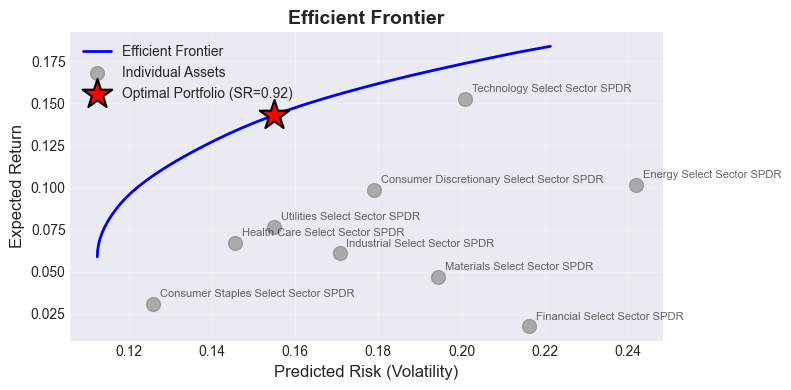

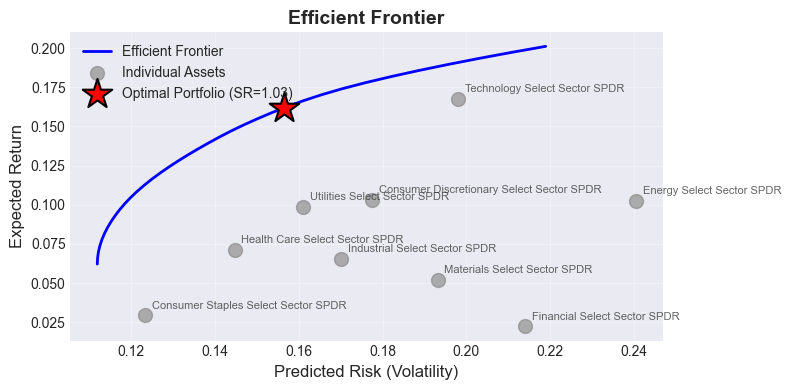

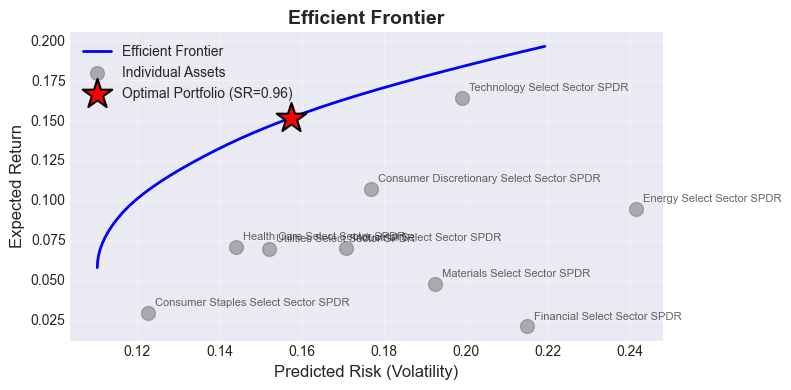

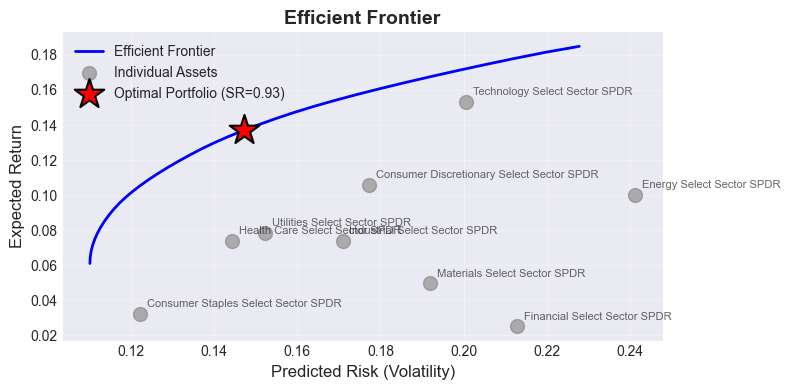

In [16]:
for rebal_date in sorted(list(BACKTEST_LOADED_2024.keys()))[::3]:
    long = BACKTEST_LOADED_2024[rebal_date].optimal_weights.where(lambda x: x>=0).sum().round(2) * 100
    short = BACKTEST_LOADED_2024[rebal_date].optimal_weights.where(lambda x: x<0).abs().sum().round(2) * 100
    print(f"{pd.Timestamp(rebal_date).date()}:\tlong/short = {long}/{short}")
    print(f"-----------")
    print(BACKTEST_LOADED_2024[rebal_date].optimal_weights.sort_values(ascending=False).round(4).to_string())
    display(BACKTEST_LOADED_2024[rebal_date].plot_efficient_frontier(figsize=(8, 4), show_assets=True))

2024-11-01:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.4869
Utilities Select Sector SPDR                 0.2843
Consumer Discretionary Select Sector SPDR    0.2725
Energy Select Sector SPDR                    0.1070
Health Care Select Sector SPDR               0.0993
Consumer Staples Select Sector SPDR          0.0000
Industrial Select Sector SPDR               -0.0000
Materials Select Sector SPDR                -0.0586
Financial Select Sector SPDR                -0.1914


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

2025-02-05:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.5246
Utilities Select Sector SPDR                 0.3052
Consumer Discretionary Select Sector SPDR    0.2378
Energy Select Sector SPDR                    0.0997
Health Care Select Sector SPDR               0.0827
Industrial Select Sector SPDR               -0.0000
Consumer Staples Select Sector SPDR         -0.0000
Materials Select Sector SPDR                -0.0536
Financial Select Sector SPDR                -0.1964


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

2025-05-07:	long/short = 125.0/25.0
-----------
Health Care Select Sector SPDR               0.6517
Technology Select Sector SPDR                0.2797
Utilities Select Sector SPDR                 0.2632
Energy Select Sector SPDR                    0.0553
Consumer Discretionary Select Sector SPDR   -0.0000
Industrial Select Sector SPDR               -0.0000
Materials Select Sector SPDR                -0.0000
Consumer Staples Select Sector SPDR         -0.0000
Financial Select Sector SPDR                -0.2500


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

2025-08-07:	long/short = 125.0/25.0
-----------
Technology Select Sector SPDR                0.5224
Utilities Select Sector SPDR                 0.3192
Health Care Select Sector SPDR               0.2644
Energy Select Sector SPDR                    0.1062
Consumer Discretionary Select Sector SPDR    0.0378
Consumer Staples Select Sector SPDR          0.0000
Industrial Select Sector SPDR                0.0000
Materials Select Sector SPDR                -0.0900
Financial Select Sector SPDR                -0.1600


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

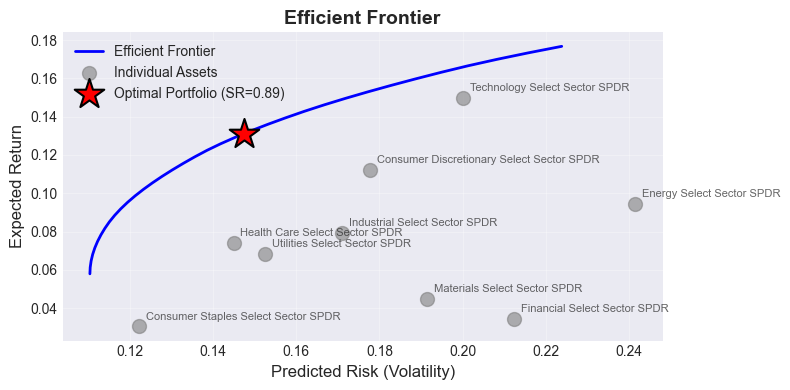

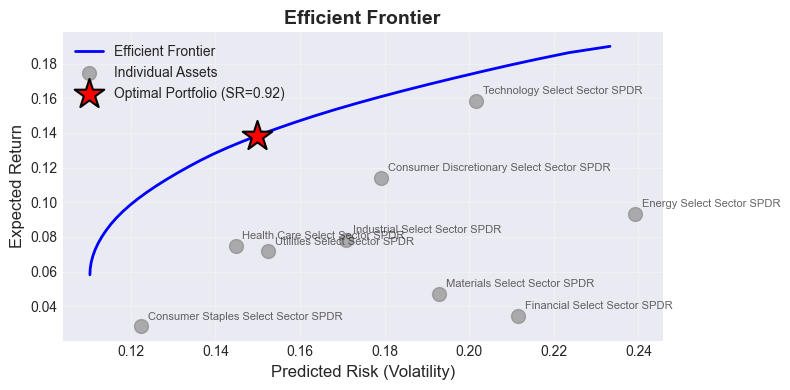

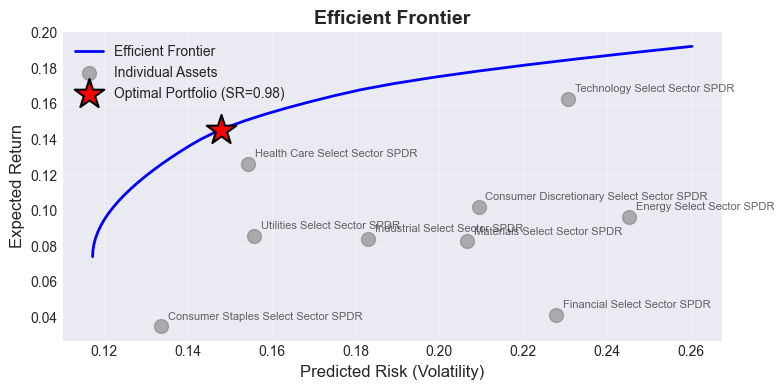

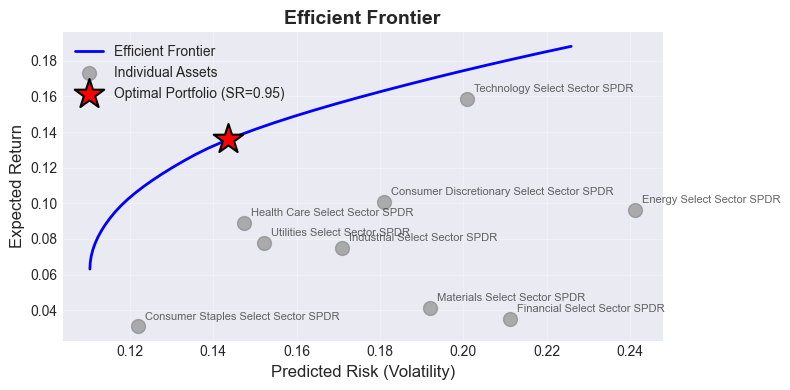

In [17]:
for rebal_date in sorted(list(BACKTEST_LOADED_2025.keys()))[::3]:
    long = BACKTEST_LOADED_2025[rebal_date].optimal_weights.where(lambda x: x>=0).sum().round(2) * 100
    short = BACKTEST_LOADED_2025[rebal_date].optimal_weights.where(lambda x: x<0).abs().sum().round(2) * 100
    print(f"{pd.Timestamp(rebal_date).date()}:\tlong/short = {long}/{short}")
    print(f"-----------")
    print(BACKTEST_LOADED_2025[rebal_date].optimal_weights.sort_values(ascending=False).round(4).to_string())
    display(BACKTEST_LOADED_2025[rebal_date].plot_efficient_frontier(figsize=(8, 4), show_assets=True))

#### Distribution & Simulation Validation

In [18]:
list(BACKTEST_LOADED_2025.keys())

['20241101',
 '20241203',
 '20250103',
 '20250205',
 '20250307',
 '20250407',
 '20250507',
 '20250606',
 '20250709',
 '20250807',
 '20250908',
 '20251007']

In [19]:
BACKTEST_LOADED_2025[list(BACKTEST_LOADED_2025.keys())[-1]].assets

['Energy Select Sector SPDR',
 'Financial Select Sector SPDR',
 'Utilities Select Sector SPDR',
 'Industrial Select Sector SPDR',
 'Health Care Select Sector SPDR',
 'Technology Select Sector SPDR',
 'Materials Select Sector SPDR',
 'Consumer Discretionary Select Sector SPDR',
 'Consumer Staples Select Sector SPDR']

In [25]:
dte = list(BACKTEST_LOADED_2025.keys())[-1]
asset = BACKTEST_LOADED_2025[dte].assets[5]

print(f"Validating distributions for {asset} on {pd.Timestamp(dte).date()}")
dist_validation = BACKTEST_LOADED_2025[dte]\
    .optimizer_inputs_instance.simulators[asset].validate_distributions(verbose=True)

dist_validation

Validating distributions for Technology Select Sector SPDR on 2025-10-07

DISTRIBUTION GOODNESS-OF-FIT VALIDATION

Parameter Validity & Sample Size:
 regime distribution  n_obs  valid
      0 norminvgauss   4235   True
      1    student_t   1217   True
      2    student_t    307   True
      3 norminvgauss    971   True

Goodness-of-Fit Tests:
 regime  KS_pval  QQ_corr
      0 0.429133 0.996684
      1 0.528492 0.996528
      2 0.113360 0.996292
      3 0.964225 0.990184

Interpretation:
  - KS p-value > 0.05: Distribution fits well (cannot reject)
  - KS p-value < 0.05: Distribution may not fit well (reject)
  - QQ_corr > 0.95: Excellent fit
  - QQ_corr > 0.90: Good fit

✓ All distributions pass goodness-of-fit tests

DISTRIBUTION GOODNESS-OF-FIT VALIDATION

Parameter Validity & Sample Size:
 regime distribution  n_obs  valid
      0 norminvgauss   4235   True
      1    student_t   1217   True
      2    student_t    307   True
      3 norminvgauss    971   True

Goodness-of-Fit Te

,regime,distribution,n_obs,valid,KS_stat,KS_pval,QQ_corr,loc,scale,AIC
0,0,norminvgauss,4235,True,0.013396,0.429133,0.996684,0.002416,0.012176,NaN
1,1,student_t,1217,True,0.023074,0.528492,0.996528,0.001373,0.012258,NaN
2,2,student_t,307,True,0.067819,0.113360,0.996292,-0.003835,0.023225,NaN
3,3,norminvgauss,971,True,0.015864,0.964225,0.990184,-0.014401,0.060631,NaN


In [ ]:
# sim_validation = BACKTEST_LOADED[REBAL_DATES[-1]].optimizer_inputs_instance.validate_copula_simulation(verbose=True)